 [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239232-lesson-6-agent)

# 智能体

## 回顾

我们构建了一个路由

* 我们的对话模型将根据用户的输入来决定是否进行工具调用
* 我们使用条件边来路由到调用我们的工具的节点或直接结束的节点。

![Screenshot 2024-08-21 at 12.44.33 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac0ba0bd34b541c448cc_agent1.png)

## 目标

现在，我们可以将其扩展为一个通用的智能体架构。

在之前的路由中，我们调用了模型，如果它选择调用工具，我们就向用户返回一个`ToolMessage`。
 
但是，如果我们简单地将那个`ToolMessage`*反馈给模型*会怎样呢？

我们可以让它要么 (1) 调用另一个工具或(2)直接响应。

这就是[ReAct](https://react-lm.github.io/)（一个通用的智能体架构）背后的思想
  
* `act` - 让模型调用特定工具
* `observe` - 将工具输出传递回模型
* `reason` - 让模型对工具输出进行推理以决定下一步操作（例如，调用另一个工具或直接响应）

这种[通用架构](https://blog.langchain.dev/planning-for-agents/)可以应用于多种类型的工具。

![Screenshot 2024-08-21 at 12.45.43 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbac0b4a2c1e5e02f3e78b_agent2.png)

In [22]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph langgraph-prebuilt

In [ ]:
# 官方的配置方式，由用户输入openai的api key，然后设置到环境变量
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [1]:
# 我没有openai的api key，所以使用qwen的openai兼容接口，需要设置qwen的api key和base url，我选择从配置文件.yml中读取
import os, yaml

with open('../.yml', 'r') as file:
    config = yaml.safe_load(file)

# 获取配置信息(以.yml_example的例子)
qwen_config = config['llm']['qwen']

这里，我们将使用[LangSmith](https://docs.smith.langchain.com/)进行[追踪](https://docs.smith.langchain.com/concepts/tracing).

我们将记录到一个项目`langchain-study`。

In [2]:

smith_config = config['langsmith']
# _set_env("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = smith_config['key']
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-study"

In [3]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="qwen-max", api_key=qwen_config['api_key'], base_url=qwen_config['base_url'], temperature=0.1)

# For this ipynb we set parallel tool calling to false as math generally is done sequentially, and this time we have 3 tools that can do math
# the OpenAI model specifically defaults to parallel tool calling for efficiency, see https://python.langchain.com/docs/how_to/tool_calling_parallel/
# play around with it and see how the model behaves with math equations!
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

让我们创建我们的LLM，并用总体期望的智能体行为来提示它。

In [4]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

与之前一样，我们使用`MessagesState`并定义一个包含我们的工具列表的`Tools`节点。

该`Assistant`节点只是我们的模型，附带工具。

我们使用`Assistant`节点和`Tools`节点创建一个图。

我们添加`tools_condition`边, 该边根据`Assistant`是否调用工具来决定路由到`End`还是`Tools`。

现在，我们添加一个新的步骤:

我们将`Tools`节点连接*回*`Assistant`，形成一个循环。

* 在`assistant`节点执行之后，`tools_condition`检查模型的输出是否是一次工具调用
* 如果是一次工具调用，流程将导向`tools`节点。
* 该`tools`节点再连接回`assistant`。
* 如果模型一直决定调用工具，这个循环会一直持续。
* 如果模型的响应不是一次工具调用，流程将转向END，终止进程。

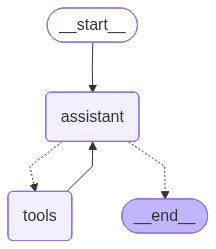

In [5]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [6]:
# messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2. Divide the output by 5")]
messages = [HumanMessage(content="计算：(3+4+3)*2/5")]
messages = react_graph.invoke({"messages": messages})

In [8]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

计算：(3+4+3)*2/5
================================== Ai Message ==================================
Tool Calls:
  add (call_982db68296f34e7381be99)
 Call ID: call_982db68296f34e7381be99
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  add (call_bcd3016ea1fa46ec9e3af6)
 Call ID: call_bcd3016ea1fa46ec9e3af6
  Args:
    a: 7
    b: 3
================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================
Tool Calls:
  multiply (call_426631d621544d36bf0515)
 Call ID: call_426631d621544d36bf0515
  Args:
    a: 10
    b: 2
================================= Tool Message =================================
Name: multiply

20
=============================

## LangSmith

我们可以在 LangSmith 中查看痕迹。

![Screenshot .png](./image.png)

![Screenshot .png](./image2.png)
